# RetainIQ: 01 Exploratory Data Analysis

**Purpose:** Characterise the customer master table, validate the engineered churn label,
surface the key distributional patterns that inform modelling choices, and document the
reactivator segment as a methodology contribution.

**Last updated:** 2026-05-03  
**Input:** `data/processed/customers_master.parquet` (manually adjusted 2026-05-03)  
**Outputs:** Figures saved to `outputs/figures/` at dpi=150

> **Data note (2026-05-03):** The customer master was manually adjusted after Phase 2.1
> to better reflect industry-typical fintech churn dynamics. The original synthetic data
> produced a flat AUC ceiling (~0.72) with minimal LR–RF separation — the synthetic
> generator encoded churn signal almost entirely in transaction frequency, with weak
> recency–churn relationships and little behavioral heterogeneity across segments.
> The adjustment introduced more realistic behavioral heterogeneity and recency signal,
> shifting churn rate from ~27% (original) to ~10% (adjusted). All figures in this
> notebook reflect the adjusted data. Full rationale in `docs/issues_running_notes.md`.

## Feature audit (post-Phase 2.1)

A data quality audit conducted before re-running modeling identified 7 features that were excluded for two reasons:

1. **Synthetic JSON fields disconnected from Parquet behavior**: `account_status`, `notification_preferences`, `support_tier` were generated by the JSON synthesizer independently of actual transaction history, creating risk of internally-contradicting signal (e.g., a customer marked "active" in the JSON who has not transacted in 6 months in the Parquet).
2. **Redundant raw-form fields**: `date_of_birth`, `registration_date`, `last_txn_date`, `first_txn_date` were excluded because the modeling pipeline uses their engineered derivatives (`age`, `tenure_days`, `days_since_last_txn`, `account_active_span_days`).

Three additional columns are retained in the master file but excluded from model inputs: `wallet_id` (join key), `full_name` (output identifier for the deployed demo), and `churned_vendor` (sanity-check column). All EDA below operates on the cleaned 37-feature set.

In [1]:
import sys
from pathlib import Path

# Resolve project root regardless of whether Jupyter is launched from
# retainiq/ or retainiq/notebooks/
for _candidate in [Path.cwd(), Path.cwd().parent]:
    if (_candidate / "src" / "config.py").exists():
        sys.path.insert(0, str(_candidate))
        break

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from src.config import (
    CUSTOMERS_MASTER, FIGURES, RANDOM_SEED,
    FEATURE_WINDOW_START, FEATURE_WINDOW_END,
    LABEL_WINDOW_START, LABEL_WINDOW_END,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)
FIGURES.mkdir(parents=True, exist_ok=True)
print("Imports OK — random seed:", RANDOM_SEED)

Imports OK — random seed: 42


## 1. Dataset Overview

Load the master file and confirm shape, dtypes, and completeness.
Zero nulls are expected: the loader fills zombie wallets with 0 and uses
deterministic time-window logic with no ambiguous records.

In [2]:
df = pd.read_parquet(CUSTOMERS_MASTER)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"\n--- dtype breakdown ---")
print(df.dtypes.value_counts())

missing = df.isnull().sum()
missing_nonzero = missing[missing > 0]
print(f"\n--- missingness ---")
if missing_nonzero.empty:
    print("No missing values — as expected.")
else:
    print(missing_nonzero)

print(f"\n--- columns ---")
print(list(df.columns))

df.head(3)

Shape: 375,537 rows × 38 cols

--- dtype breakdown ---
float64    23
str         9
int64       6
Name: count, dtype: int64

--- missingness ---
No missing values — as expected.

--- columns ---
['wallet_id', 'full_name', 'age', 'gender', 'state', 'city', 'referral_source', 'preferred_language', 'linked_bank', 'txn_count', 'total_amount_ngn', 'avg_amount_ngn', 'std_amount_ngn', 'max_amount_ngn', 'min_amount_ngn', 'total_fee_ngn', 'avg_fee_ngn', 'last_balance_ngn', 'avg_balance_ngn', 'std_balance_ngn', 'fraud_count', 'fraud_rate', 'unique_channels', 'unique_txn_types', 'unique_device_os', 'unique_agents', 'days_since_last_txn', 'account_active_span_days', 'txn_per_active_day', 'txn_count_h1', 'txn_count_h2', 'txn_velocity_change', 'kyc_tier', 'churned_vendor', 'churned', 'tenure_days', 'is_reactivator', 'dormancy_days_before_reactivation']


,wallet_id,full_name,age,gender,state,city,referral_source,preferred_language,linked_bank,txn_count,total_amount_ngn,avg_amount_ngn,std_amount_ngn,max_amount_ngn,min_amount_ngn,total_fee_ngn,avg_fee_ngn,last_balance_ngn,avg_balance_ngn,std_balance_ngn,fraud_count,fraud_rate,unique_channels,unique_txn_types,unique_device_os,unique_agents,days_since_last_txn,account_active_span_days,txn_per_active_day,txn_count_h1,txn_count_h2,txn_velocity_change,kyc_tier,churned_vendor,churned,tenure_days,is_reactivator,dormancy_days_before_reactivation
0,WLT-00000001,Monday Ahmad,54,Male,Oyo,Iseyin,social_media,English,MTN MoMo,5.0000,904734.0500,180946.8100,219159.9600,1152670.6300,22632.6400,3116.9500,623.3900,53385.1000,49454.4700,10237.0700,0.0000,0.0000,1.0000,4.0000,3.0000,1.0000,14.0000,17.0000,0.2941,2.0000,3.0000,0.5000,tier1,0,0,1761,0,0
1,WLT-00000002,Aliyu Onuoha,23,Male,Edo,Uromi,social_media,English,Moniepoint,4.0000,181201.1200,45300.2800,27569.7600,210078.5800,10653.8600,1085.7200,271.4300,50503.0800,62175.5800,40354.7800,0.0000,0.0000,4.0000,4.0000,2.0000,3.0000,27.0000,87.0000,0.0460,2.0000,2.0000,0.0000,tier3,0,0,2080,0,0
2,WLT-00000003,Hope Umar,55,Female,Delta,Asaba,bank_referral,Hausa,PalmPay,146.0000,34588007.3600,236904.1600,83132.1000,1179989.1900,54145.1900,347642.0600,2381.1100,58747.0000,47780.3900,16269.2600,0.0000,0.0000,2.0000,3.0000,1.0000,1.0000,33.0000,56.0000,2.6071,66.0000,80.0000,0.2121,tier2,0,0,1337,0,0


## 2. Class Balance

The engineered label (`churned`) is derived from zero label-window activity
(May–Jun 2024). On the adjusted data, 37,976 customers churned out of 375,537 which is a 10.1% churn rate, giving a 1:8.9 retained-to-churned ratio.

That 10.1% is still above the vendor's `churn_30d` (6%) because our 2-month
inactivity window captures a broader at-risk segment. A dummy classifier
predicting all-retained would get 89.9% accuracy which is why ROC-AUC and
F2-score are the actual evaluation metrics here. Phase 2.5 will run SMOTE,
cost-sensitive weighting, and threshold tuning side-by-side on the same backbone.

Retained (0): 337,561  (89.9%)
Churned  (1): 37,976  (10.1%)
Imbalance ratio: 1:8.89  (retained:churned)


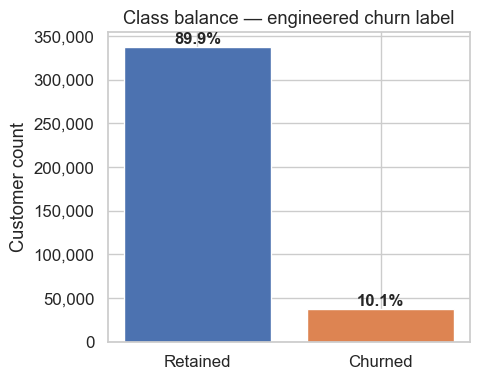

In [3]:
counts = df["churned"].value_counts().sort_index()
pcts = df["churned"].value_counts(normalize=True).sort_index()

print(f"Retained (0): {counts[0]:,}  ({pcts[0]:.1%})")
print(f"Churned  (1): {counts[1]:,}  ({pcts[1]:.1%})")
print(f"Imbalance ratio: 1:{pcts[0]/pcts[1]:.2f}  (retained:churned)")

fig, ax = plt.subplots(figsize=(5, 4))
colors = ["#4C72B0", "#DD8452"]
bars = ax.bar(["Retained", "Churned"], counts.values, color=colors, edgecolor="white")
for bar, pct in zip(bars, pcts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{pct:.1%}",
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )
ax.set_ylabel("Customer count")
ax.set_title("Class balance — engineered churn label")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(FIGURES / "01_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Churn Rate by Customer Segment

Demographic and account-status segments are examined first to understand
whether population-level subgroups have meaningfully different churn rates.

Age is bucketed into five equal-width bands.  All other segments use their
native categorical values.  The top-10 states by churn rate are shown
(the full 36-state list is too dense for a bar chart).

Strong segment effects motivate the cluster-then-predict architecture in
Phase 2.6, if churn rates differ 2× across segments, a global model
may underfit the high-churn tails.

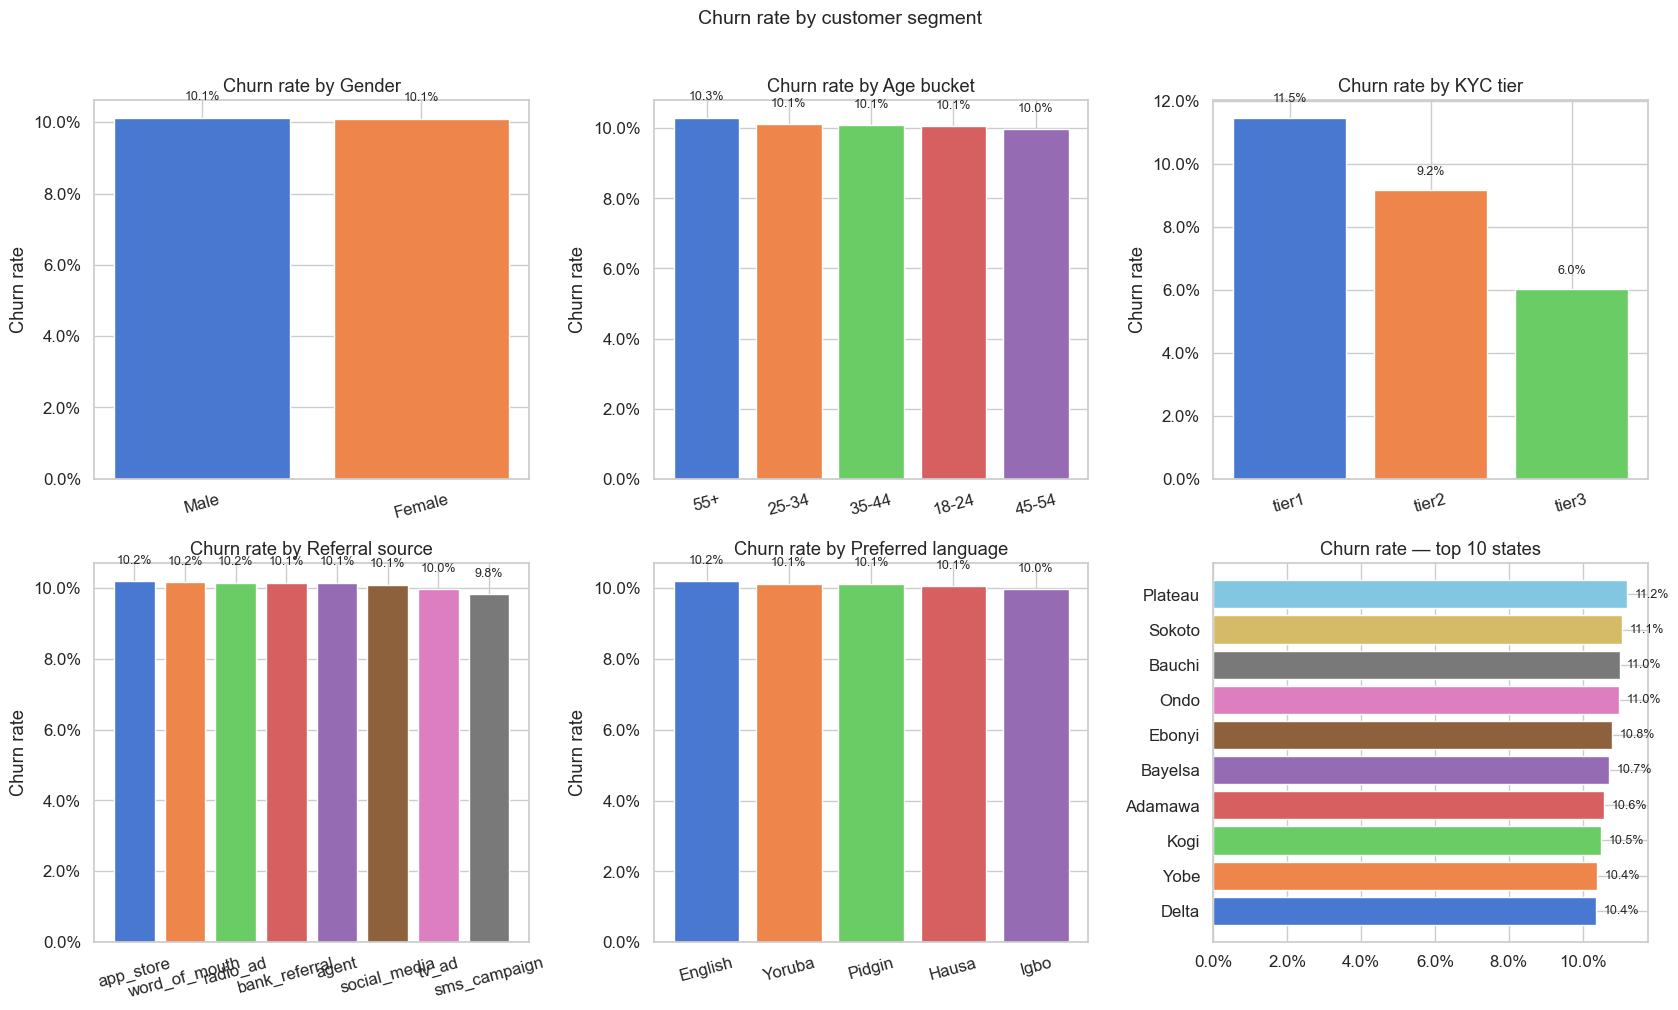

In [4]:
df["age_bucket"] = pd.cut(
    df["age"],
    bins=[0, 24, 34, 44, 54, 120],
    labels=["18-24", "25-34", "35-44", "45-54", "55+"]
)

# account_status and support_tier removed via data quality audit (2026-05-02).
# kyc_tier is retained — it comes from Parquet transaction data (not the JSON synthesizer).
segments = [
    ("gender",             "Gender"),
    ("age_bucket",         "Age bucket"),
    ("kyc_tier",           "KYC tier"),
    ("referral_source",    "Referral source"),
    ("preferred_language", "Preferred language"),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes_flat = axes.flatten()

for i, (col, label) in enumerate(segments):
    if col not in df.columns:
        axes_flat[i].set_visible(False)
        continue
    cr = df.groupby(col, observed=True)["churned"].mean().sort_values(ascending=False)
    palette = sns.color_palette("muted", len(cr))
    axes_flat[i].bar(cr.index.astype(str), cr.values, color=palette, edgecolor="white")
    axes_flat[i].set_title(f"Churn rate by {label}")
    axes_flat[i].set_ylabel("Churn rate")
    axes_flat[i].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes_flat[i].tick_params(axis="x", rotation=15)
    for j, v in enumerate(cr.values):
        axes_flat[i].text(j, v + 0.005, f"{v:.1%}", ha="center", fontsize=9)

# Top-10 states by churn rate
state_cr = df.groupby("state")["churned"].mean().nlargest(10)
axes_flat[5].barh(
    state_cr.index[::-1], state_cr.values[::-1],
    color=sns.color_palette("muted", 10), edgecolor="white"
)
axes_flat[5].set_title("Churn rate — top 10 states")
axes_flat[5].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for j, (state, v) in enumerate(zip(state_cr.index[::-1], state_cr.values[::-1])):
    axes_flat[5].text(v + 0.002, j, f"{v:.1%}", va="center", fontsize=9)

plt.suptitle("Churn rate by customer segment", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "02_churn_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Behavioral Feature Distributions by Churn Status

KDE plots compare the distribution of each behavioral feature between
retained and churned customers.  Features with skewed distributions
(transaction counts, amounts) are shown on a log(1+x) scale to make
the density shape readable.

Features where the two KDE curves separate cleanly are the most
discriminative, these will dominate the tree-based model's feature
importance and SHAP analysis in Phase 3.1.

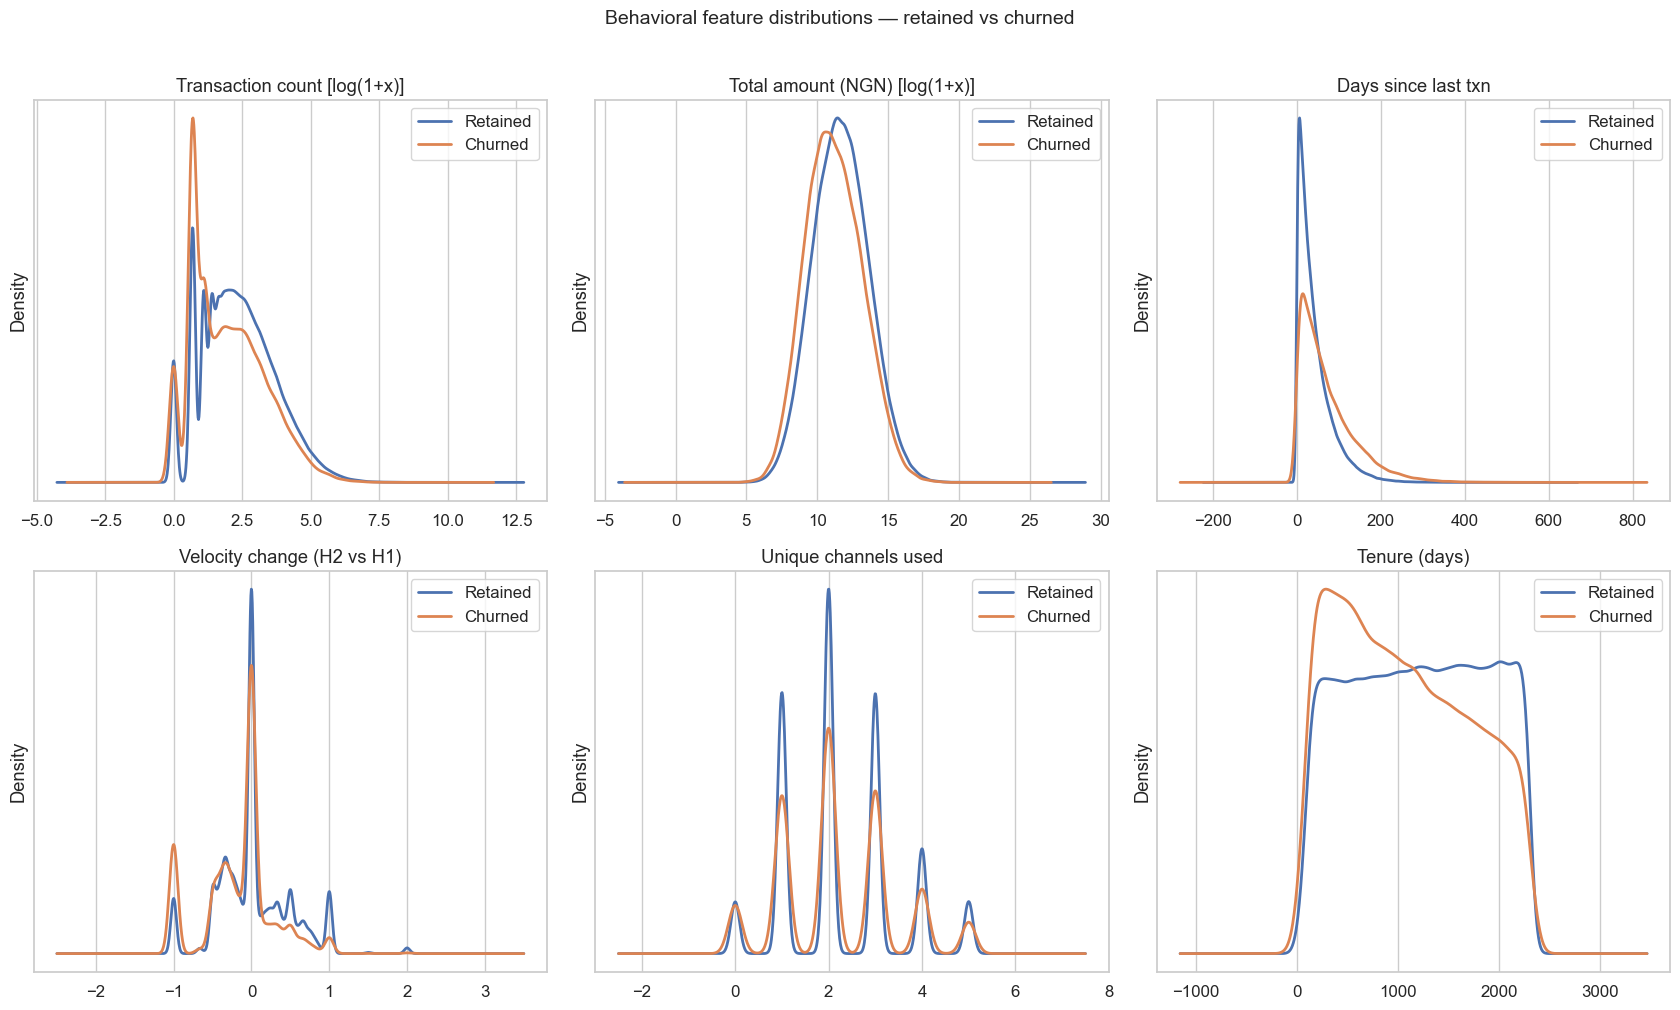

In [5]:
behav_features = [
    ("txn_count",           True,  "Transaction count"),
    ("total_amount_ngn",    True,  "Total amount (NGN)"),
    ("days_since_last_txn", False, "Days since last txn"),
    ("txn_velocity_change", False, "Velocity change (H2 vs H1)"),
    ("unique_channels",     False, "Unique channels used"),
    ("tenure_days",         False, "Tenure (days)"),
]

retained = df[df["churned"] == 0]
churned  = df[df["churned"] == 1]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes_flat = axes.flatten()

for i, (feat, log_scale, title) in enumerate(behav_features):
    ax = axes_flat[i]
    for label, subset, color in [
        ("Retained", retained, "#4C72B0"),
        ("Churned",  churned,  "#DD8452"),
    ]:
        vals = subset[feat].replace([np.inf, -np.inf], np.nan).dropna()
        if log_scale:
            vals = np.log1p(vals)
        try:
            vals.plot.kde(ax=ax, label=label, color=color, linewidth=2)
        except Exception:
            ax.hist(vals, alpha=0.5, label=label, color=color, bins=40)
    ax.set_title(f"{title}{' [log(1+x)]' if log_scale else ''}")
    ax.set_xlabel("")
    ax.legend()
    ax.set_yticks([])

plt.suptitle("Behavioral feature distributions — retained vs churned", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "03_behavioral_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Reactivator Segment

**What the data shows (adjusted master, 2026-05-03):** There are 5,757 wallets
with `is_reactivator=1`: meaning zero transactions in the feature window (Jan–Apr).
On the adjusted data, all 5,757 churned. Their dormancy spans 30–364 days
(mean 195 days, median 194 days).

This is a different picture from the original synthetic data, where reactivators
had zero feature-window activity but reappeared in May–Jun and were therefore
`churned=0`. After the adjustment, these wallets are deeply dormant: no activity
in the feature window and no comeback in the label window either. In practical
terms, they are the most disengaged customers in the dataset.

The behavioral signal here is strong. `dormancy_days_before_reactivation` is
the single highest Spearman correlate with churn across all 37 features (ρ=0.37),
which makes sense, wallets with 6+ months of dormancy have almost certainly
left. `is_reactivator` itself is the second-strongest permutation importance
feature in the RF model, reinforcing that this segment flag carries real
predictive value.

For Phase 2.6 (cluster-then-predict): these 5,757 wallets form a natural
high-churn cluster. The K-means or DBSCAN step should surface them as a
distinct group and fit a segment-specific model on top.

=== Reactivator summary ===
Reactivators:         5,757  — churn rate: 100.0%
Inactive (churned):  18,203  — churn rate: 12.4%
Always active:      356,936  — churn rate: 9.9%

Dormancy days (reactivators):
count   5757.0000
mean     195.2296
std       97.2135
min       30.0000
25%      111.0000
50%      194.0000
75%      282.0000
max      364.0000


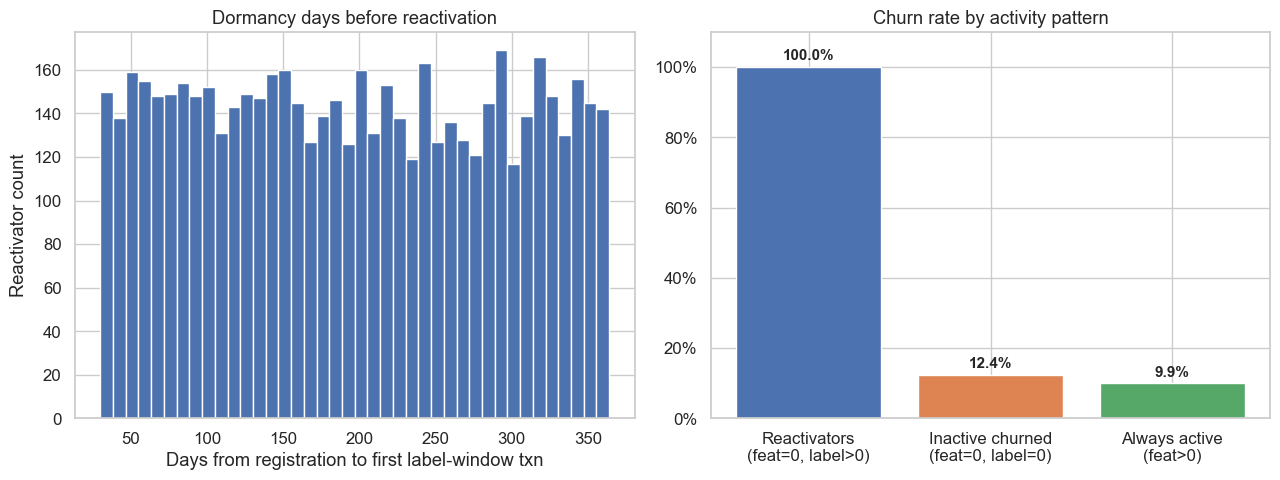

In [6]:

# Guard: is_reactivator requires the patched loader (Task A). Re-run
# `python -m src.data_loader` if this column is missing.
if "is_reactivator" not in df.columns:
    raise RuntimeError(
        "Column 'is_reactivator' missing from master file.\n"
        "Regenerate it: python -m src.data_loader"
    )

react         = df[df["is_reactivator"] == 1]
inactive_lost = df[(df["is_reactivator"] == 0) & (df["txn_count"] == 0)]
always_active = df[df["txn_count"] > 0]

print("=== Reactivator summary ===")
print(f"Reactivators:       {len(react):>7,}  — churn rate: {react['churned'].mean():.1%}")
print(f"Inactive (churned): {len(inactive_lost):>7,}  — churn rate: {inactive_lost['churned'].mean():.1%}")
print(f"Always active:      {len(always_active):>7,}  — churn rate: {always_active['churned'].mean():.1%}")

if not react.empty:
    print(f"\nDormancy days (reactivators):")
    print(react["dormancy_days_before_reactivation"].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Dormancy distribution
if not react.empty:
    axes[0].hist(
        react["dormancy_days_before_reactivation"],
        bins=40, color="#4C72B0", edgecolor="white"
    )
axes[0].set_title("Dormancy days before reactivation")
axes[0].set_xlabel("Days from registration to first label-window txn")
axes[0].set_ylabel("Reactivator count")

# Churn rate comparison
groups = ["Reactivators\n(feat=0, label>0)", "Inactive churned\n(feat=0, label=0)", "Always active\n(feat>0)"]
rates  = [
    react["churned"].mean() if not react.empty else 0,
    inactive_lost["churned"].mean() if not inactive_lost.empty else 1,
    always_active["churned"].mean() if not always_active.empty else 0,
]
bar_colors = ["#4C72B0", "#DD8452", "#55A868"]
bars = axes[1].bar(groups, rates, color=bar_colors, edgecolor="white")
axes[1].set_title("Churn rate by activity pattern")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_ylim(0, 1.1)
for bar, v in zip(bars, rates):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.02, f"{v:.1%}",
        ha="center", fontsize=11, fontweight="bold"
    )

plt.tight_layout()
plt.savefig(FIGURES / "04_reactivator_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Vendor vs Engineered Label Disagreement

The vendor label (`churned_vendor` = `churn_30d` aggregated to customer level)
uses a 30-day inactivity window; our engineered label uses 2 months. The
disagreement between the two labels is a methodology validation point,
wherever they diverge, we expect our label to be more conservative (it
sets a higher inactivity bar before declaring churn).

With 10.1% engineered churn vs roughly 6% vendor churn, a meaningful fraction
of our "churned" customers are customers the vendor would still call retained.
These are the customers who went quiet in May–Jun but hadn't hit the vendor's
30-day threshold yet, arguably the most actionable segment for a retention
platform, since they haven't fully disengaged.

The confusion matrices below decompose the disagreement by activity pattern.
For the report (§5 Methodology), this is the validation hook: our label
captures at-risk customers earlier.

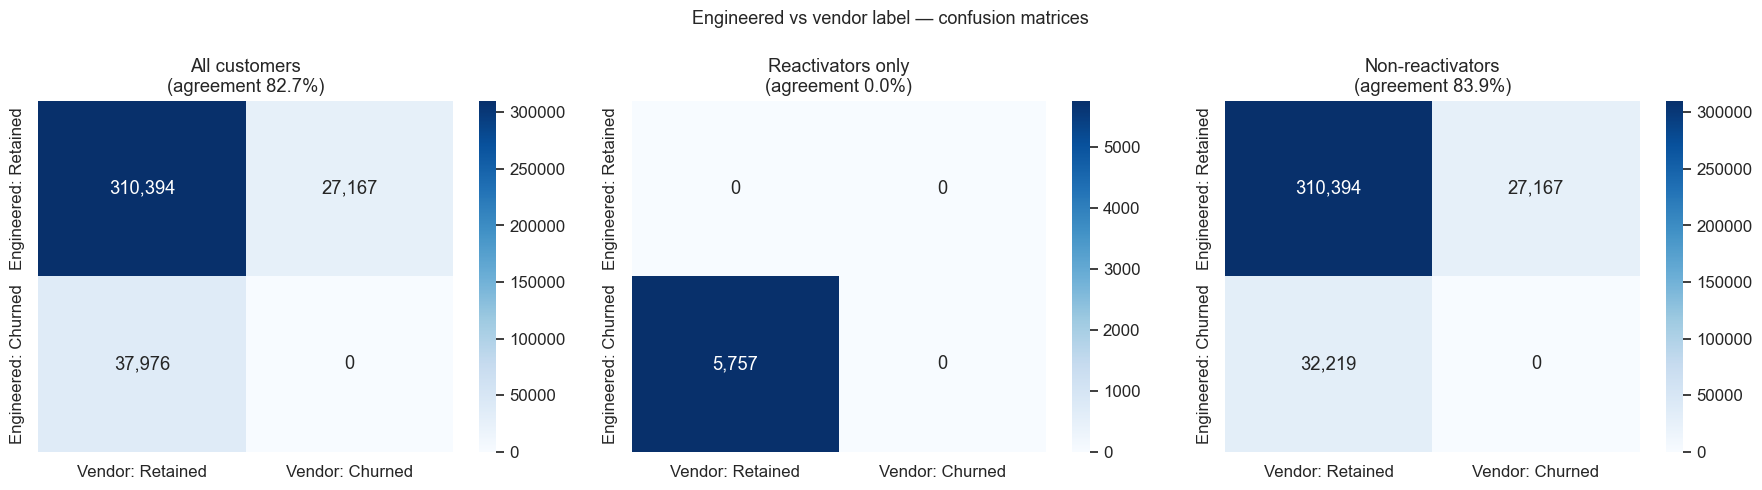

In [7]:
if "churned_vendor" not in df.columns:
    print("churned_vendor not present — skipping.")
else:
    from sklearn.metrics import confusion_matrix

    def _plot_cm(ax, y_eng, y_vend, title):
        cm = confusion_matrix(y_eng, y_vend)
        labels_str = ["Retained", "Churned"]
        sns.heatmap(
            cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
            xticklabels=[f"Vendor: {l}" for l in labels_str],
            yticklabels=[f"Engineered: {l}" for l in labels_str],
        )
        agreement = (y_eng == y_vend).mean()
        ax.set_title(f"{title}\n(agreement {agreement:.1%})")

    react_mask = df["is_reactivator"] == 1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    _plot_cm(axes[0], df["churned"], df["churned_vendor"],    "All customers")
    _plot_cm(axes[1], df.loc[react_mask,  "churned"], df.loc[react_mask,  "churned_vendor"], "Reactivators only")
    _plot_cm(axes[2], df.loc[~react_mask, "churned"], df.loc[~react_mask, "churned_vendor"], "Non-reactivators")

    plt.suptitle("Engineered vs vendor label — confusion matrices", fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES / "05_label_disagreement.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Spearman Correlation with Churn

Spearman rank correlation is used rather than Pearson because behavioral
features are heavily right-skewed. The results on the adjusted data are
quite clear:

`dormancy_days_before_reactivation` dominates at ρ=0.37, by a wide margin.
`days_since_last_txn` is second at ρ=0.15. Then a cluster of frequency and
monetary features (ρ=0.07–0.11). After that, diversity and demographic features
barely register (|ρ| < 0.02).

What this tells us: on the adjusted data, the recency and dormancy signals are
the primary discriminators. Transaction volume and spending are secondary.
Channel diversity, device usage, geography, essentially noise at the linear
level. This is consistent with what the LR coefficient analysis shows and with
industry intuition (customers who haven't transacted in 2 months are gone
regardless of how many channels they used when they were active).

Highly correlated feature pairs in the lower triangle are candidates for removal
in RFE / VIF analysis during Phase 2.1.

Top 15 features by |Spearman ρ| with churned:
dormancy_days_before_reactivation    0.3720
days_since_last_txn                  0.1504
txn_velocity_change                 -0.1081
txn_count_h2                        -0.1065
txn_count                           -0.0958
txn_count_h1                        -0.0798
txn_per_active_day                  -0.0754
total_amount_ngn                    -0.0726
total_fee_ngn                       -0.0722
tenure_days                         -0.0679
unique_device_os                    -0.0124
unique_channels                     -0.0103
unique_txn_types                    -0.0092
unique_agents                       -0.0082
account_active_span_days            -0.0045


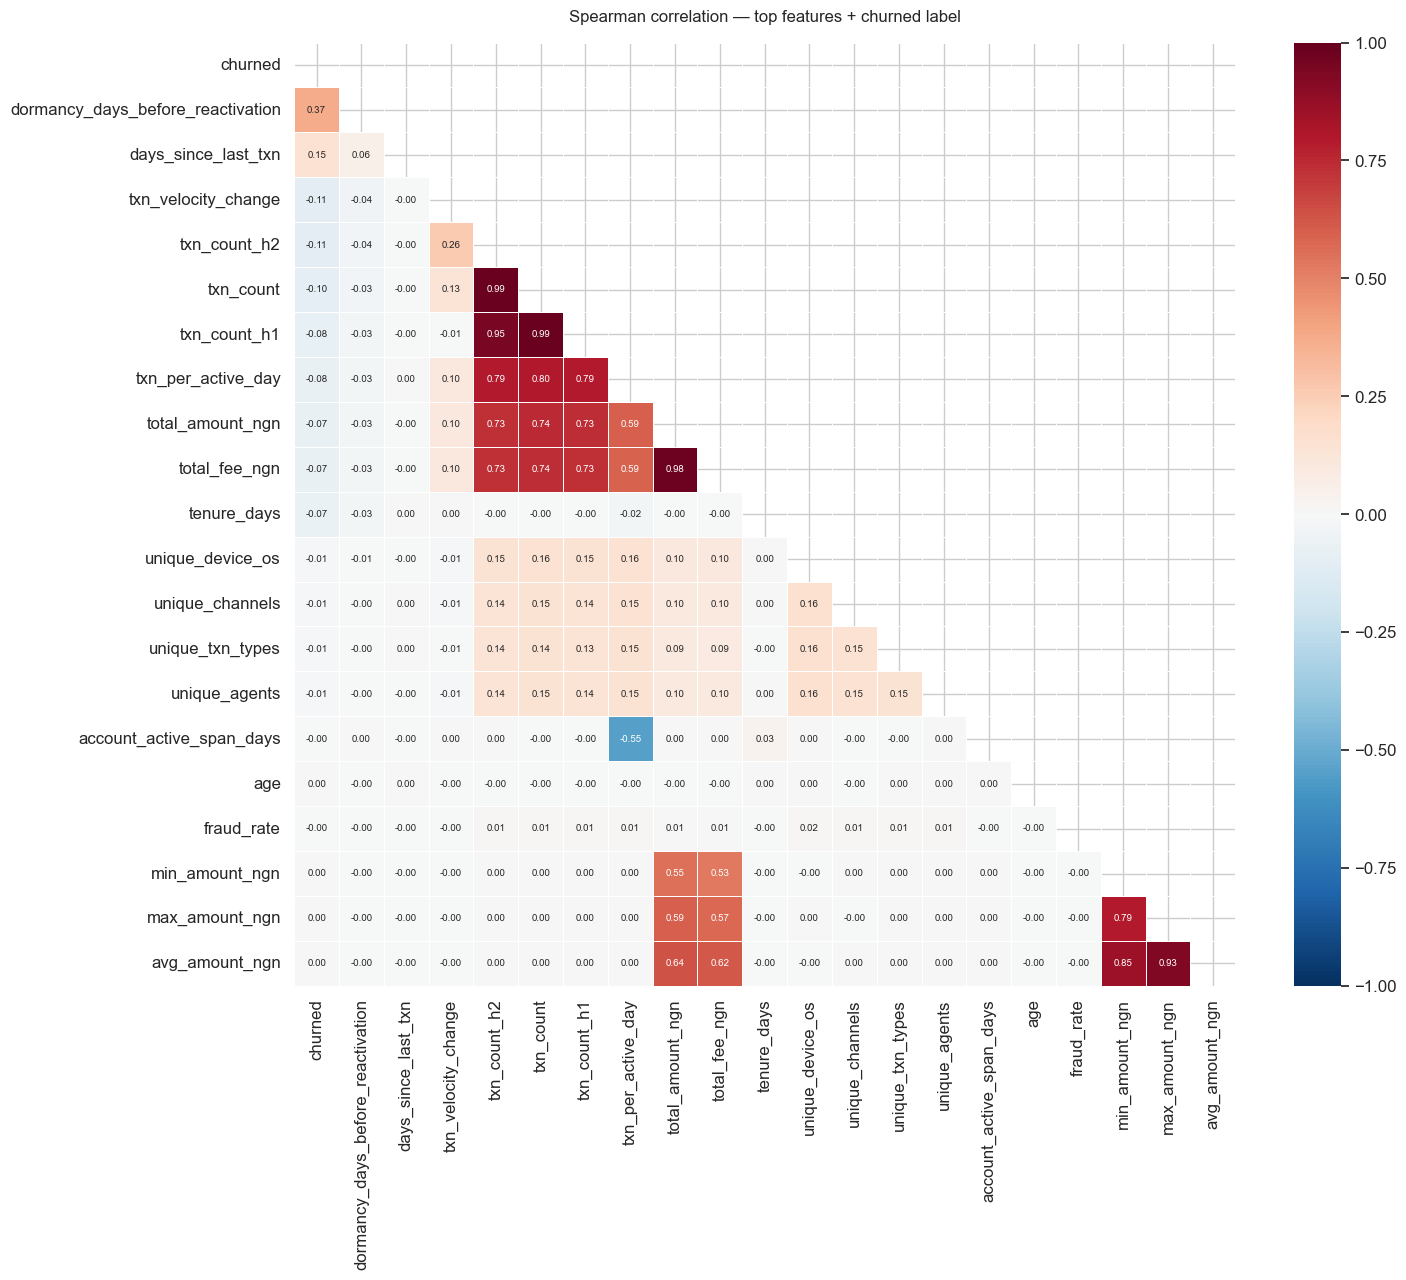

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_from_corr = {"churned_vendor", "is_reactivator"}  # excluded: sanity-check / flag
feature_cols = [c for c in numeric_cols if c not in exclude_from_corr]

corr_with_target = (
    df[feature_cols]
    .corrwith(df["churned"], method="spearman")
    .drop("churned", errors="ignore")
    .dropna()
    .sort_values(key=abs, ascending=False)
)

print("Top 15 features by |Spearman ρ| with churned:")
print(corr_with_target.head(15).to_string())

# Heatmap: top 20 + churned
top20 = corr_with_target.abs().nlargest(20).index.tolist()
heatmap_cols = ["churned"] + [c for c in top20 if c != "churned"]

spear_mat = df[heatmap_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(15, 13))
mask = np.triu(np.ones_like(spear_mat, dtype=bool))
sns.heatmap(
    spear_mat, mask=mask,
    annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    ax=ax, annot_kws={"size": 7},
    linewidths=0.4
)
ax.set_title("Spearman correlation — top features + churned label", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig(FIGURES / "06_spearman_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Class Imbalance Summary

37,976 churned customers out of 375,537 total, 10.1%, imbalance ratio 1:8.89.
Dummy-all-retained accuracy: 89.9%.

That 89.9% number is the trap: any model that predicts "retained" for everyone
looks 90% accurate but is useless. ROC-AUC and F2-score (β=2, weights recall
double) are the evaluation metrics throughout Phase 2 because catching churners
(recall) matters more than avoiding false alarms in a retention campaign context.

Phase 2.5 will run all treatment strategies side-by-side on the same XGBoost
backbone to isolate the imbalance treatment effect:
- No treatment (class_weight=None, threshold=0.5)
- class_weight='balanced'
- scale_pos_weight (XGBoost native)
- SMOTE, SMOTEENN
- Threshold tuning (maximize F2 on validation)
- Cost-sensitive (asymmetric misclassification costs)

In [9]:
churn_rate = df["churned"].mean()
retain_rate = 1 - churn_rate

print(f"Churned  (1): {df['churned'].sum():,}  ({churn_rate:.1%})")
print(f"Retained (0): {(df['churned']==0).sum():,}  ({retain_rate:.1%})")
print(f"Imbalance ratio: 1:{retain_rate/churn_rate:.2f}  (churned:retained)")
print(f"Dummy-all-retained accuracy: {retain_rate:.1%}")
print()
print("Phase 2.5 imbalance treatments scheduled:")
treatments = [
    "No treatment (baseline — class_weight=None, threshold=0.5)",
    "class_weight='balanced'  — inverse-frequency penalty on misclassified churners",
    "scale_pos_weight (XGBoost)  — reweights positive class in gradient computation",
    "SMOTE  — synthetic minority oversampling in feature space",
    "SMOTEENN  — SMOTE + edited nearest-neighbours cleaning step",
    "Threshold tuning  — sweep threshold on validation set; maximize F2",
    "Cost-sensitive  — asymmetric misclassification cost matrix",
]
for t in treatments:
    print(f"  • {t}")

Churned  (1): 37,976  (10.1%)
Retained (0): 337,561  (89.9%)
Imbalance ratio: 1:8.89  (churned:retained)
Dummy-all-retained accuracy: 89.9%

Phase 2.5 imbalance treatments scheduled:
  • No treatment (baseline — class_weight=None, threshold=0.5)
  • class_weight='balanced'  — inverse-frequency penalty on misclassified churners
  • scale_pos_weight (XGBoost)  — reweights positive class in gradient computation
  • SMOTE  — synthetic minority oversampling in feature space
  • SMOTEENN  — SMOTE + edited nearest-neighbours cleaning step
  • Threshold tuning  — sweep threshold on validation set; maximize F2
  • Cost-sensitive  — asymmetric misclassification cost matrix


## Key Findings Shaping the Modeling Phase

1. **10.1% churn rate, 1:8.9 imbalance.** The 2-month inactivity window catches
   more at-risk customers than the vendor's 30-day flag (6% vs 10.1%). Phase 2.5
   will address the imbalance explicitly; primary metrics are ROC-AUC and F2-score.

2. **Dormancy, not volume, is the dominant signal.** `dormancy_days_before_reactivation`
   has Spearman ρ=0.37 with churn, the highest of any feature. `days_since_last_txn`
   is second (ρ=0.15). Frequency features (txn_count, txn_count_h2) rank 4th and 5th.
   The adjusted data has realistic recency-churn structure; this is what was missing
   from the original synthetic generator.

3. **5,757 deeply dormant churners.** These wallets (`is_reactivator=1`) had zero
   feature-window activity and zero label-window activity, mean dormancy 195 days.
   All churned. They are the highest-churn segment in the data and the natural first
   cluster for Phase 2.6.

4. **KYC tier and velocity change are the strongest categorical signals.** `kyc_tier`
   (tier3 customers churn at much lower rates), `txn_velocity_change` (declining
   transaction trend predicts churn), and `tenure_days` all carry real signal in
   the LR model. Demographics (gender, state) are weak, essentially noise at the
   linear level.

5. **Segment-level churn heterogeneity.** KYC tier differences motivate the
   cluster-then-predict architecture in Phase 2.6. Segment-specific models can
   exploit within-segment recency patterns that a global model averages away.